In [1]:
from notebooks.features.feature_extraction import load_all_features

loaded_features = load_all_features(version='oligo', n_jobs=-1)

In [8]:
import pandas as pd

from notebooks.consts import OLIGO_CSV_INDEXED

data = pd.read_csv(OLIGO_CSV_INDEXED)

In [9]:
data.columns

Index(['aso_sequence_5_to_3', 'inhibition_percent', 'chemistry', 'custom_id',
       'target_mrna', 'target_gene', 'cell_line', 'cell_line_species',
       'dosage', 'cells_per_well', 'transfection_method', 'steric_blocking',
       'rna_context', 'sugar_mods', 'backbone_mods', 'Canonical Gene Name',
       'index_oligo'],
      dtype='object')

In [12]:
import pandas as pd

merged_df = pd.merge(loaded_features, data, on='index_oligo')

In [13]:
from notebooks.preprocessing import process_oligo_data

final_data = process_oligo_data(merged_df)

------------------------------------------------------------
PROCESSING FILTERING REPORT
------------------------------------------------------------
Initial raw rows loaded: 159,510

[0. BASE FILTERING]
Unsupported chemistry (Mixmers/DNA/None): 20,040
Steric blocking (True) eliminated: 0
Multiple genes (';' present) eliminated: 785
Missing inhibition (NaN) eliminated: 0
Missing cell line (NaN) eliminated: 4,159

[1. UNMAPPED SEQUENCES (sense_start == -1)]
Samples eliminated: 752

[2. COHORT FILTERING (>= 1 samples)]
Cohorts: 254 -> 254 (0 eliminated)
Samples: 133,774 -> 133,774 (0 eliminated)

[3. SPARSE CELL LINE FILTERING (>= 1 samples)]
Cell Lines: 29 -> 29 (0 eliminated)
Samples: 133,774 -> 133,774 (0 eliminated)

FINAL DATASET: 133,774 ASOs

ELIMINATED GROUPS BREAKDOWN

[ELIMINATED UNMAPPED SAMPLES] - 752 samples across 10 genes:
  • KCNQ2: 460 samples
  • IGF2-AS: 69 samples
  • RP11-739B23.1: 59 samples
  • MIR6801: 54 samples
  • RP11-823E8.3: 52 samples
  • F12: 21 samples
  

Total rows involved in a repeat: 16393

Columns that differ among identical sequences:
Inhibition(%)          5826
Chemical_Pattern       1691
sugar_mods             1691
cells_per_well         1365
transfection_method    1219
backbone_mods          1079
Cell_line               822
target_mrna             404
Canonical Gene Name      70
rna_context              58
Modification             32
dtype: int64


/tmp/ipykernel_420293/3699890345.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=difference_summary.values, y=difference_summary.index, palette='viridis')


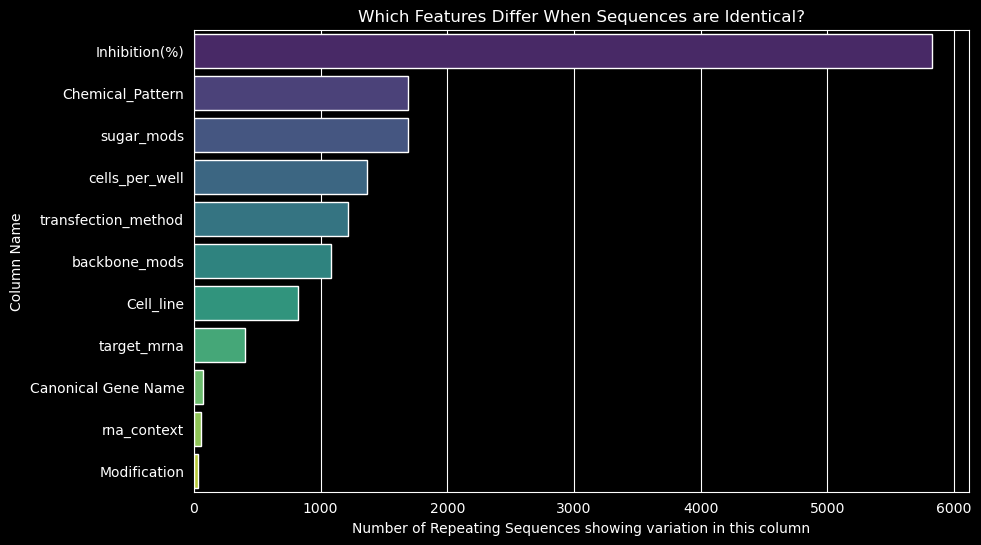

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tauso.data.consts import *

# 1. Define exactly the columns you care about
expected_columns = [
    SEQUENCE, INHIBITION, CHEMICAL_PATTERN, MODIFICATION, 'custom_id',
    'target_mrna', CANONICAL_GENE, CELL_LINE, 'cell_line_species',
    'dosage', 'cells_per_well', 'transfection_method', 'steric_blocking',
    'rna_context', 'sugar_mods', 'backbone_mods', 'index_oligo'
]

# Safety Check: Only keep columns that actually exist in final_data to prevent KeyErrors
# (Just in case 'aso_sequence_5_to_3' is actually stored in the SEQUENCE variable!)
cols_to_keep = [c for c in expected_columns if c in final_data.columns]
if SEQUENCE not in cols_to_keep and SEQUENCE in final_data.columns:
    cols_to_keep.append(SEQUENCE)

# Minimize dataframe to JUST your columns
df = final_data[cols_to_keep].copy()

# 2. Keep ONLY the rows where the sequence appears more than once
duplicates_df = df[df.duplicated(subset=[SEQUENCE], keep=False)]
print(f"Total rows involved in a repeat: {len(duplicates_df)}")

# 3. Group by the sequence and count unique values in all other columns
differences = duplicates_df.groupby(SEQUENCE).nunique()

# 4. Ignore columns we expect to be unique anyway (IDs) and the sequence itself
ignore_cols = [SEQUENCE, 'custom_id', 'index_oligo']
cols_to_check = [c for c in df.columns if c not in ignore_cols]

# 5. Find which columns have variations (nunique > 1) for the same sequence
differing_columns = differences[cols_to_check] > 1

# 6. Summarize how often each column is the reason for a difference
difference_summary = differing_columns.sum().sort_values(ascending=False)
difference_summary = difference_summary[difference_summary > 0] # Keep only columns that differ

print("\nColumns that differ among identical sequences:")
print(difference_summary)

# 7. Plot the differences
if not difference_summary.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=difference_summary.values, y=difference_summary.index, palette='viridis')
    plt.title('Which Features Differ When Sequences are Identical?')
    plt.xlabel('Number of Repeating Sequences showing variation in this column')
    plt.ylabel('Column Name')
    plt.show()
else:
    print("No differences found in the specified columns.")

In [24]:
# 1. Define the columns that make up the "Experimental Setup"
# We want to find rows where ALL of these are identical
exclude_from_match = [INHIBITION, 'custom_id', 'index_oligo']
condition_cols = [c for c in df.columns if c not in exclude_from_match]

# 2. Find rows where EVERYTHING in the condition_cols is perfectly identical.
# keep=False ensures we keep all copies of the replicates so we can compare them.
true_replicates = df[df.duplicated(subset=condition_cols, keep=False)]

print(f"Number of rows that are exact biological/technical replicates: {len(true_replicates)}")

# 3. Sort them so the identical conditions are grouped together
if not true_replicates.empty:
    # Sorting makes it easy for your eyes to compare the grouped rows
    true_replicates_sorted = true_replicates.sort_values(by=condition_cols + [INHIBITION])

    # We don't need to print every column to the screen to learn from it.
    # Let's just display the sequence, chemistry, dosage, and the differing result:
    display_cols = [SEQUENCE, CHEMICAL_PATTERN, 'dosage', INHIBITION]

    print("\nHere is a peek at the replicates (showing key columns):")
    # Using .head(15) so it doesn't flood your screen
    display(true_replicates_sorted[display_cols].head(15))
else:
    print("No exact replicates found. If sequences repeat, something in the chemistry/dosage/etc. is also changing.")

Number of rows that are exact biological/technical replicates: 9454

Here is a peek at the replicates (showing key columns):


KeyError: "['dosage'] not in index"

In [6]:
data.columns

Index(['index_oligo', 'CAI_score_20_CDS', 'CAI_score_30_CDS',
       'CAI_score_40_CDS', 'CAI_score_50_CDS', 'CAI_score_60_CDS',
       'CAI_score_70_CDS', 'CAI_score_global_CDS', 'CET_DIFF_37_HYBR',
       'DNA_HYBR_DIFF',
       ...
       'rna_context', 'sugar_mods', 'backbone_mods', 'Canonical Gene Name',
       'Chemical_Pattern', 'Modification', 'ps_pattern', 'cohort_id',
       'Cell_Line_Depmap_Proxy', 'Cell_Line_Depmap'],
      dtype='object', length=646)

In [4]:
from tauso.data.consts import *

# 3. Handle Transfection Features (Convert Boolean -> Int)
transfection_features = ['Electroporation', 'Gymnosis', 'Lipofection', 'Other']

# --- NEW LINE HERE ---
# Force conversion of True/False to 1/0
data[transfection_features] = data[transfection_features].astype(int)
# ---------------------

# 4. Define Final Feature List
features_to_ignore = ['index_oligo', INHIBITION, 'inhibition_percent', 'dosage']

# Note: Assuming 'merged_df' is your final dataframe. If you are just using 'data', change this to 'data'.
features = [
               col for col in data.select_dtypes(include=['number']).columns
               if col not in features_to_ignore
           ] + transfection_features + [VOLUME]

# Ensure uniqueness
features = sorted(list(set(features)))

KeyError: "None of [Index(['Electroporation', 'Gymnosis', 'Lipofection', 'Other'], dtype='object')] are in the [columns]"